In [16]:
import numpy as np
import pandas as pd

In [17]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [18]:
class Neuron():
    def __init__(self,
                 input_size: int,
                 activation=sigmoid):

        self.weights = np.random.rand(input_size)
        self.bias = 0.0
        self.activation = activation
        self.output = None

    def forward(self, inputs):
        inputs = np.asarray(inputs)
        self.output = self.activation(np.dot(self.weights, inputs) + self.bias)
        return self.output

    def set_weights(self, weights):
        self.weights = weights

    def set_bias(self, bias):
        self.bias = bias

    def set_activation(self, activation):
        self.activation = activation

    def get_weights(self):
        return self.weights

    def get_bias(self):
        return self.bias

    def get_activation(self):
        return self.activation

    def __str__(self):
        return f"Neuron(weights={self.weights}, bias={self.bias}, activation={self.activation.__name__})"

In [19]:
class Layer():
    def __init__(self,
                 n_neurons: int,
                 input_size: int):

        self.n_neurons = n_neurons
        self.neurons = [Neuron(input_size=input_size) for _ in range(n_neurons)]

    def forward(self, inputs):
        self.outputs = np.array([neuron.forward(inputs) for neuron in self.neurons])
        return self.outputs

    def set_neuron_weights(self, neuron_index, weights):
        self.neurons[neuron_index].set_weights(weights)
    def set_neuron_bias(self, neuron_index, bias):
        self.neurons[neuron_index].set_bias(bias)
    def get_weights(self):
        weights = []
        for neuron in self.neurons:
            weights.append(neuron.weights)
        return weights
    def get_bias(self):
        bias = []
        for neuron in self.neurons:
            bias.append(neuron.bias)
        return bias

    def __str__(self):
        return f"Layer(n_neurons={self.n_neurons}, neurons = {str(self.neurons)}"

In [20]:
class SimpleNetwork():
    def __init__(self,
                 input_size: int,
                 hidden_layers_sizes: list,
                 output_size: int = 1):

        self.input_size = input_size
        self.hidden_layers_sizes = hidden_layers_sizes
        self.output_size = output_size

        self.hidden_layers = []
        prev_size = input_size

        for size in hidden_layers_sizes:
            layer = Layer(n_neurons=size, input_size=prev_size)
            self.hidden_layers.append(layer)
            prev_size = size

        self.output_layer = Layer(n_neurons=output_size, input_size=prev_size)

    def predict(self, inputs):
        current_inputs = np.asarray(inputs)

        for layer in self.hidden_layers:
            current_inputs = layer.forward(current_inputs)

        output = self.output_layer.forward(current_inputs)
        return output

    def __str__(self):
        return f"SimpleNetwork(input_size={self.input_size}, hidden_layers_sizes={self.hidden_layers_sizes})"

In [21]:
train_data = pd.read_csv('../datasets/regression/square-simple-training.csv')


In [22]:
#normalizacja
x = train_data['x']
y = train_data['y']


x_min = x.min()
x_max = x.max()
y_min = y.min()
y_max = y.max()

x_normalized = (x - x_min) / (x_max - x_min)
y_normalized = (y - y_min) / (y_max - y_min)

In [23]:
Network = SimpleNetwork(
    input_size=1,
    hidden_layers_sizes=[5],
    output_size=1
)
print(Network)

SimpleNetwork(input_size=1, hidden_layers_sizes=[5])


In [24]:
y_pred = []
for i in range(len(train_data['x'])):
    y_pred.append(
        Network.predict(inputs = x_normalized[i])[0][0] * (y_max - y_min) + y_min
                  )


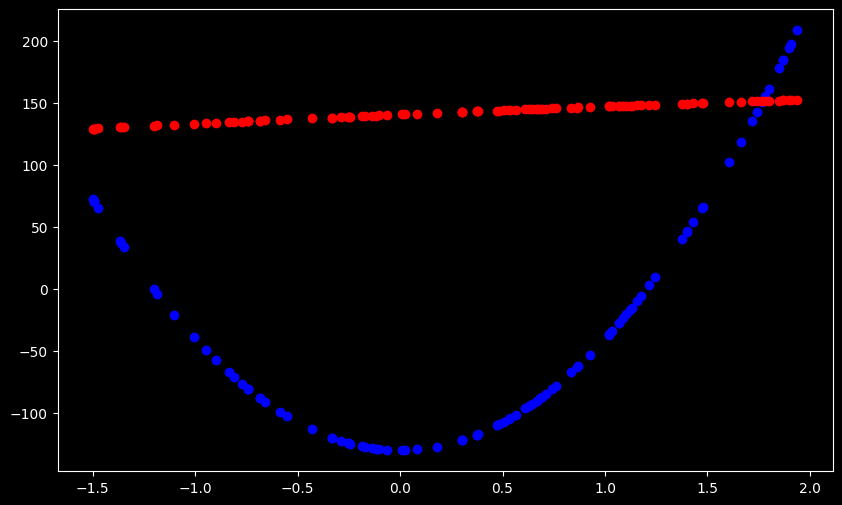

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(train_data['x'], train_data['y'], c ='blue')
plt.scatter(train_data['x'], y_pred, c ='red')
plt.show()


In [26]:
Network.hidden_layers[0].get_weights()

[array([0.93849928]),
 array([0.58805871]),
 array([0.56857752]),
 array([0.32000153]),
 array([0.94734624])]

In [27]:
Network.hidden_layers[0].get_bias()

[0.0, 0.0, 0.0, 0.0, 0.0]

In [28]:
Network.hidden_layers[0].set_neuron_weights(0, 1.122874)
Network.hidden_layers[0].set_neuron_weights(1, -8.693646)
Network.hidden_layers[0].set_neuron_weights(2, -21.678741 )
Network.hidden_layers[0].set_neuron_weights(3, -5.0275292)
Network.hidden_layers[0].set_neuron_weights(4, -23.350372)

Network.hidden_layers[0].set_neuron_bias(0, 1.3382 )
Network.hidden_layers[0].set_neuron_bias(1,  0.8137 )
Network.hidden_layers[0].set_neuron_bias(2, 22.8079 )
Network.hidden_layers[0].set_neuron_bias(3,  2.3012 )
Network.hidden_layers[0].set_neuron_bias(4, 7.4620 )

In [29]:
Network.output_layer.set_neuron_weights(0, [  5.8391547,   8.030438,  -11.130382,  -11.501838,   4.5621433])
Network.output_layer.set_neuron_bias(0, 7.2160)

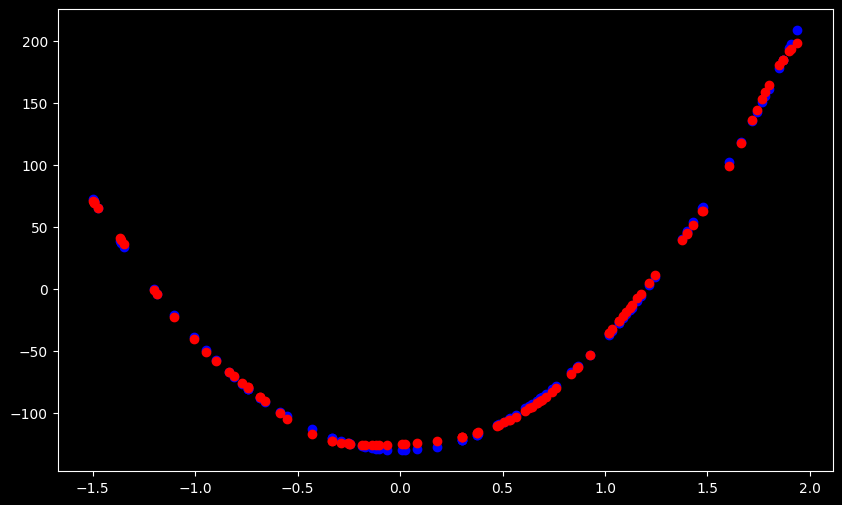

In [30]:
y_pred = []
for i in range(len(train_data['x'])):
    y_pred.append(
        Network.predict(inputs = x_normalized[i])[0] * (y_max - y_min) + y_min
                  )

plt.figure(figsize=(10, 6))
plt.scatter(train_data['x'], train_data['y'], c ='blue')
plt.scatter(train_data['x'], y_pred, c ='red')
plt.show()